# CH 6 - The Problem of Erroneous Knowledge in Objective Technical Analysis

## Objectif pédagogique

Ce notebook explique une idée centrale de David Aronson : une **analyse technique objective** peut produire une connaissance valide, mais seulement si elle traite correctement le **hasard**, la **variabilité d'échantillonnage** et le **biais de minage de données**.

> **Idée centrale :** un backtest profitable ne prouve pas automatiquement qu'une règle de trading possède un vrai pouvoir prédictif.

Dans ce notebook, on va transformer cette idée en intuition concrète avec une simulation Python.

Nous allons montrer pourquoi une stratégie peut sembler excellente **in-sample**, puis s'effondrer **out-of-sample**, même si elle n'a aucun edge réel.


## 1. Le problème : la connaissance erronée

En trading algorithmique, on peut croire que l'ordinateur protège automatiquement contre l'erreur.

C'est faux.

Une règle peut être :

- **mécanique** ;
- **codée proprement** ;
- **testée sur des données historiques** ;
- **rentable en backtest** ;

et pourtant être totalement inutile.

Pourquoi ?

Parce que le profit observé peut venir de deux sources très différentes :

| Source du profit | Signification | Valeur prédictive |
|---|---:|---:|
| **Edge réel** | La règle capture une inefficience exploitable | Oui |
| **Chance statistique** | La règle a simplement bien coïncidé avec le passé | Non |

> **L'erreur grave consiste à confondre un profit historique avec une preuve de compétence prédictive.**


## 2. Le backtest n'est qu'un échantillon

Un **backtest** n'est pas la vérité complète du marché.

C'est seulement un **échantillon historique**.

En notation simple :

$$
\text{Performance observée} = \text{Performance réelle} + \text{erreur d'échantillonnage}
$$

Dans le cas d'une stratégie sans edge réel :

$$
\text{Performance réelle} = 0
$$

Donc :

$$
\text{Performance observée} = \text{erreur d'échantillonnage}
$$

Autrement dit, même une règle inutile peut afficher un profit positif simplement parce que le hasard lui a été favorable sur la période testée.

> **Le hasard est l'explication par défaut de tout profit de backtest tant que l'inférence statistique n'a pas montré le contraire.**


## 3. Mini-simulation : une stratégie sans edge peut gagner par hasard

Nous allons simuler une stratégie qui ne possède aucun talent.

Elle prend chaque jour une position aléatoire :

- $+1$ pour long ;
- $-1$ pour short.

Le marché simulé aura aussi une espérance nulle.

Donc, en théorie, la stratégie n'a aucun edge.

Mais sur un échantillon fini, elle peut quand même afficher un profit.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(999)

n_days = 252 * 3  # environ 3 années de trading
market_returns = np.random.normal(loc=0.0, scale=0.01, size=n_days)

random_signals = np.random.choice([-1, 1], size=n_days)
strategy_returns = random_signals * market_returns

equity_curve = (1 + strategy_returns).cumprod()

summary = pd.DataFrame({
    "Métrique": [
        "Nombre de jours",
        "Rendement cumulé",
        "Rendement moyen quotidien",
        "Volatilité quotidienne",
        "Sharpe approximatif annualisé"
    ],
    "Valeur": [
        n_days,
        equity_curve[-1] - 1,
        np.mean(strategy_returns),
        np.std(strategy_returns, ddof=1),
        np.mean(strategy_returns) / np.std(strategy_returns, ddof=1) * np.sqrt(252)
    ]
})

summary


,Métrique,Valeur
0,Nombre de jours,756.000000
1,Rendement cumulé,0.227316
2,Rendement moyen quotidien,0.000323
3,Volatilité quotidienne,0.010201
4,Sharpe approximatif annualisé,0.502528


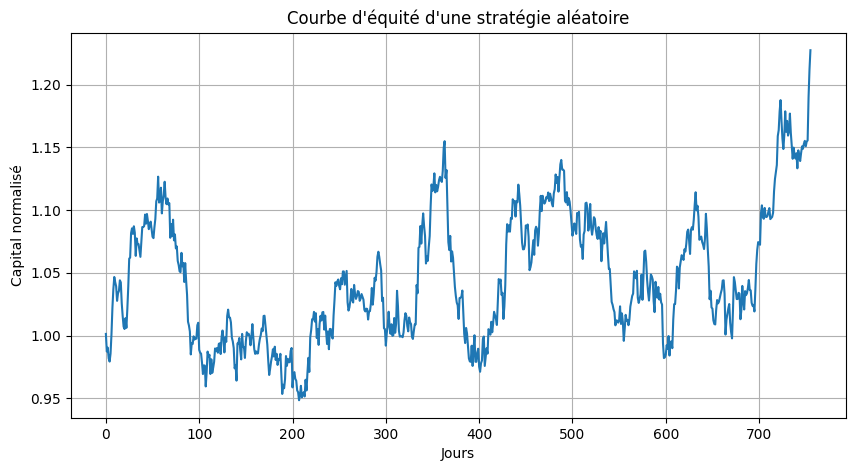

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(equity_curve)
plt.title("Courbe d'équité d'une stratégie aléatoire")
plt.xlabel("Jours")
plt.ylabel("Capital normalisé")
plt.grid(True)
plt.show()


## 4. Première leçon : un profit isolé ne suffit pas

Même si la courbe précédente finit positive, cela ne veut pas dire que la règle possède un edge.

C'est le piège central.

Une seule stratégie aléatoire peut avoir de la chance.

Mais le problème devient beaucoup plus dangereux quand on teste des centaines ou des milliers de stratégies.

C'est là qu'apparaît le **biais de minage de données**.


## 5. Le minage de données : chercher jusqu'à trouver une illusion

Supposons qu'un trader teste 1 000 stratégies.

Aucune n'a d'edge.

Mais il choisit la meilleure performance historique.

Le problème est que, parmi 1 000 essais, il y aura presque toujours une stratégie chanceuse.

Ce n'est pas une découverte.

C'est une sélection du survivant.

Mathématiquement, le trader ne regarde plus une règle aléatoire.

Il regarde le maximum de 1 000 règles aléatoires.

$$
\max(\text{stratégie}_1, \text{stratégie}_2, ..., \text{stratégie}_{1000})
$$

Et le maximum d'un grand nombre d'essais est naturellement extrême.

> **Plus tu testes de variantes, plus la meilleure performance historique est contaminée par la chance.**


In [26]:
np.random.seed(7)

n_strategies = 1000
n_days = 252 * 3

market_returns = np.random.normal(loc=0.0, scale=0.01, size=n_days)

results = []

for i in range(n_strategies):
    signals = np.random.choice([-1, 1], size=n_days)
    returns = signals * market_returns
    cumulative_return = (1 + returns).prod() - 1
    sharpe = np.mean(returns) / np.std(returns, ddof=1) * np.sqrt(252)
    results.append((i, cumulative_return, sharpe))

results_df = pd.DataFrame(results, columns=["strategie_id", "rendement_cumule", "sharpe"])

best_strategy = results_df.sort_values("rendement_cumule", ascending=False).iloc[0]

results_df.describe()


,strategie_id,rendement_cumule,sharpe
count,1000.000000,1000.000000,1000.000000
mean,499.500000,0.008621,0.022965
std,288.819436,0.271385,0.560265
min,0.000000,-0.622220,-2.007795
25%,249.750000,-0.178213,-0.339296
50%,499.500000,-0.018934,0.037595
75%,749.250000,0.152564,0.380398
max,999.000000,1.574156,2.107481


In [27]:
best_strategy


strategie_id        859.000000
rendement_cumule      1.574156
sharpe                2.107481
Name: 859, dtype: float64

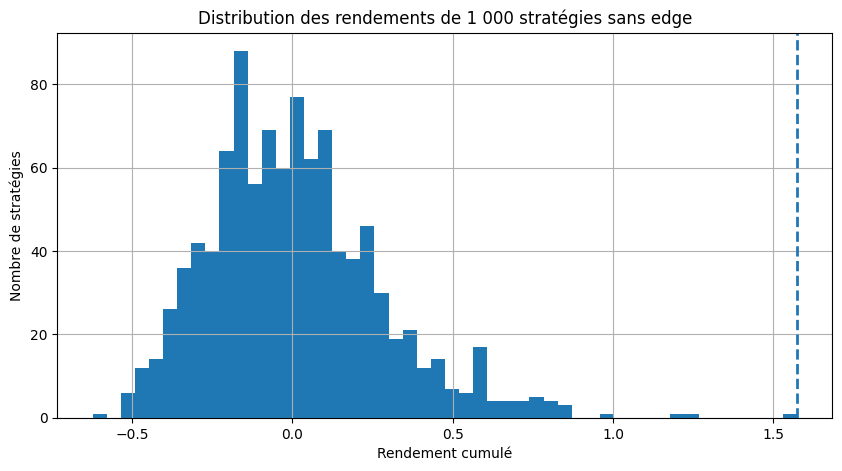

In [28]:
plt.figure(figsize=(10, 5))
plt.hist(results_df["rendement_cumule"], bins=50)
plt.axvline(best_strategy["rendement_cumule"], linestyle="--", linewidth=2)
plt.title("Distribution des rendements de 1 000 stratégies sans edge")
plt.xlabel("Rendement cumulé")
plt.ylabel("Nombre de stratégies")
plt.grid(True)
plt.show()


## 6. Eurêka : la meilleure stratégie peut être la plus chanceuse

La meilleure stratégie du groupe semble impressionnante.

Mais nous savons une chose capitale : toutes les stratégies étaient aléatoires.

Donc la meilleure n'est pas forcément intelligente.

Elle est simplement celle qui a eu le meilleur tirage.

> **Eurêka : quand on teste beaucoup de règles inutiles, la meilleure règle historique est souvent juste la règle la plus chanceuse.**

C'est exactement le danger décrit par Aronson.

Le trader croit avoir trouvé une pépite.

En réalité, il a trouvé du **métal des fous**.


## 7. Test out-of-sample : la vérité arrive après la sélection

Maintenant, nous allons faire comme un vrai chercheur.

Nous allons :

1. tester 1 000 stratégies sur une période **in-sample** ;
2. sélectionner la meilleure ;
3. appliquer exactement cette stratégie à une nouvelle période **out-of-sample**.

Pour garder une logique simple, chaque stratégie sera une séquence de signaux aléatoires en in-sample, puis une nouvelle séquence de signaux aléatoires out-of-sample.

Comme il n'existe aucun edge réel, la performance future ne devrait pas répliquer la performance passée.


In [ ]:
# ------------------------------------------------------------
# Paramétrage de la simulation
# ------------------------------------------------------------
np.random.seed(123)                     # Reproductibilité des tirages aléatoires

n_strategies = 1000                     # Nombre de stratégies à tester (business rule‑set)
n_in_sample = 252 * 3                   # Durée in‑sample  ≈ 3 ans de trading quotidien
n_out_sample = 252 * 2                  # Durée out‑sample ≈ 2 ans (validation future)

# ------------------------------
# Génération du "marché"
# ------------------------------
# Simuler les rendements quotidiens du marché (distribution normale, μ≈0, σ≈1 %)
market_in  = np.random.normal(loc=0.0, scale=0.01, size=n_in_sample)
market_out = np.random.normal(loc=0.0, scale=0.01, size=n_out_sample)

# ------------------------------
# Stockage des performances
# ------------------------------
in_sample_returns_by_strategy  = []    # Liste qui contiendra les retours in‑sample de chaque stratégie
out_sample_returns_by_strategy = []    # Idem pour la période out‑sample

# ------------------------------------------------------------
# Boucle “back‑testing” sur chaque stratégie
# ------------------------------------------------------------
for i in range(n_strategies):
    # ----- Signaux aléatoires (long / short) -----
    signals_in  = np.random.choice([-1, 1], size=n_in_sample)
    signals_out = np.random.choice([-1, 1], size=n_out_sample)

    # ----- Rendements de la stratégie = signal × mouvement du marché -----
    returns_in  = signals_in  * market_in
    returns_out = signals_out * market_out

    # ----- Accumuler les séries de rendements -----
    in_sample_returns_by_strategy.append(returns_in)
    out_sample_returns_by_strategy.append(returns_out)

# ------------------------------------------------------------
# Evaluation **in‑sample** : quelle stratégie a le meilleur rendement ?
# ------------------------------------------------------------
# Convertir chaque série de rendements en retour cumulé (1 + r)ᵖ−¹ − 1
in_sample_total_returns = np.array([
    (1 + r).prod() - 1            # Retour total de la stratégie i
    for r in in_sample_returns_by_strategy
])

best_idx = np.argmax(in_sample_total_returns)   # Index de la stratégie « gagnante »

# ------------------------------------------------------------
# Récupérer les rendements de la meilleure stratégie
# ------------------------------------------------------------
best_in_returns  = in_sample_returns_by_strategy[best_idx]   # In‑sample
best_out_returns = out_sample_returns_by_strategy[best_idx] # Out‑sample

# ------------------------------------------------------------
# Construire les courbes d’équité (capital cumulé)
# ------------------------------------------------------------
# Capital initialisé à 1.0 (100 % du capital de départ)
best_in_equity  = (1 + best_in_returns).cumprod()               # In‑sample
best_out_equity = best_in_equity[-1] * (1 + best_out_returns).cumprod()  # Out‑sample

# ------------------------------------------------------------
# Résumé des performances (tableau « comparison »)
# ------------------------------------------------------------
comparison = pd.DataFrame({
    "Période": ["In-sample", "Out-of-sample"],
    "Rendement cumulé": [
        best_in_equity[-1] - 1,                                 # Gain % in‑sample
        best_out_equity[-1] / best_in_equity[-1] - 1           # Gain % out‑sample
    ],
    "Sharpe approximatif annualisé": [
        np.mean(best_in_returns) / np.std(best_in_returns, ddof=1) * np.sqrt(252),
        np.mean(best_out_returns) / np.std(best_out_returns, ddof=1) * np.sqrt(252)
    ]
})

comparison


,Période,Rendement cumulé,Sharpe approximatif annualisé
0,In-sample,1.584904,2.095683
1,Out-of-sample,-0.281773,-0.984885


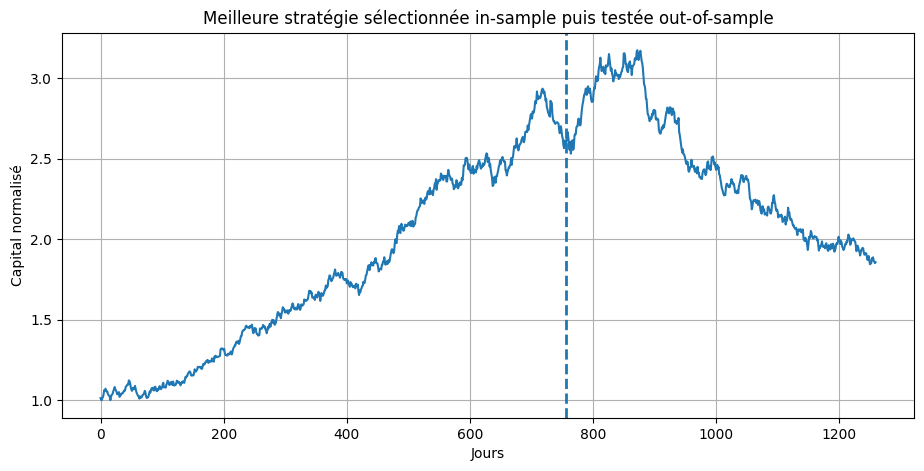

In [36]:
combined_equity = np.concatenate([best_in_equity, best_out_equity])
split_point = len(best_in_equity)

plt.figure(figsize=(11, 5))
plt.plot(combined_equity)
plt.axvline(split_point, linestyle="--", linewidth=2)
plt.title("Meilleure stratégie sélectionnée in-sample puis testée out-of-sample")
plt.xlabel("Jours")
plt.ylabel("Capital normalisé")
plt.grid(True)
plt.show()


## 8. Lecture EBTA de la courbe

La partie **in-sample** peut être très belle.

Mais cette beauté est suspecte parce qu'elle a été sélectionnée après coup parmi 1 000 essais.

La partie **out-of-sample** est plus importante, car elle représente des données nouvelles.

Si la performance chute, cela suggère que le backtest initial capturait surtout :

- de la **variabilité d'échantillonnage** ;
- du **data mining** ;
- une chance non reproductible.

> **La performance out-of-sample est le test de vérité, parce qu'elle confronte la règle à un futur qu'elle n'a pas pu optimiser.**


## 9. Pourquoi un backtest profitable est nécessaire mais insuffisant

Un backtest positif est nécessaire parce qu'une règle qui perd déjà dans le passé n'a généralement aucune raison d'être retenue.

Mais il est insuffisant parce qu'il ne répond pas aux questions essentielles :

| Question | Pourquoi elle compte |
|---|---|
| **Combien de règles ont été testées ?** | Plus il y a d'essais, plus le meilleur résultat peut être chanceux. |
| **Quelle est la p-value corrigée ?** | Elle mesure la rareté du résultat en tenant compte du hasard. |
| **La règle a-t-elle été validée out-of-sample ?** | Elle vérifie si l'effet survit à de nouvelles données. |
| **La logique économique est-elle plausible ?** | Elle évite de croire à une simple coïncidence mathématique. |
| **La performance est-elle stable ?** | Elle réduit le risque d'un effet fragile ou accidentel. |

> **Un backtest profitable est seulement le début de l'enquête, jamais la conclusion finale.**


## 10. Application pratique pour ton protocole EBTA

Voici une checklist concrète pour éviter la connaissance erronée.

| Étape | Question à poser | Danger évité |
|---|---|---|
| **1. Définir la règle avant le test** | Est-ce que les conditions sont écrites clairement ? | Ajustement narratif après coup |
| **2. Compter les essais** | Combien de variantes ai-je réellement testées ? | Biais de minage de données |
| **3. Mesurer la rareté statistique** | La performance est-elle improbable sous $H_0$ ? | Confusion entre chance et edge |
| **4. Corriger pour tests multiples** | Ai-je tenu compte du nombre de recherches ? | Faux positifs |
| **5. Isoler l'out-of-sample** | Ai-je gardé des données vraiment non touchées ? | Optimisation cachée |
| **6. Tester une seule fois la meilleure règle** | Ai-je résisté à l'envie de retoucher après l'OOS ? | Contamination du test final |
| **7. Suivre la performance live** | Le comportement réel ressemble-t-il au backtest ? | Illusion historique |

> **La discipline scientifique du trader consiste à protéger son cerveau contre les histoires trop belles racontées par ses propres backtests.**


## 11. Exemple mental : le gagnant du loto

L'analogie du loto est parfaite.

Si tu observes le gagnant après le tirage, tu peux toujours inventer une histoire :

- il portait une veste rouge ;
- il a joué un mardi ;
- il a choisi les anniversaires de sa famille ;
- il a acheté son ticket dans une ville précise.

Mais cette histoire est construite après coup.

Elle explique le passé sans prédire le futur.

C'est pareil avec le **data mining**.

Tu observes la stratégie gagnante après 1 000 essais, puis tu crois que ses paramètres ont une signification profonde.

> **Le cerveau humain adore transformer une coïncidence sélectionnée après coup en explication intelligente.**


## 12. Conclusion

La thèse d'Aronson est brutale mais libératrice.

L'**analyse technique objective** peut devenir une connaissance valide.

Mais seulement si elle est accompagnée d'une vraie rigueur statistique.

Sans cela, elle produit une forme sophistiquée d'illusion :

- des règles codées proprement ;
- des graphiques convaincants ;
- des backtests rentables ;
- mais aucune capacité prédictive réelle.

> **L'Eurêka final : la rigueur informatique ne suffit pas. Une stratégie n'est pas validée parce qu'elle a gagné dans le passé, mais parce qu'elle survit au hasard, au data mining et à l'épreuve out-of-sample.**


## 13. Résumé ultra-simple

Un robot peut gagner en backtest par chance.

Si tu testes 1 000 robots, tu trouveras presque forcément un champion historique.

Mais ce champion peut être comme un gagnant du loto : impressionnant après coup, inutile pour prédire le futur.

La vraie question n'est donc pas :

> **Combien la stratégie a gagné en backtest ?**

La vraie question est :

> **Cette performance est-elle trop rare pour être expliquée par le hasard, même après avoir tenu compte du nombre d'essais ?**


## Annexe — Source originale collée

### **CH 6 : THE PROBLEM OF ERRONEOUS KNOWLEDGE IN OBJECTIVE TECHNICAL ANALYSIS**

Voici l'analyse technique de la section traitant des failles de l'analyse technique (AT) objective. David Aronson y démontre que même une méthode rigoureuse et informatisée peut conduire à des croyances totalement erronées si les statistiques sont mal interprétées.

#### **Idées clés :**
*   **Potentiel vs Réalité :** L'AT objective a le *potentiel* de constituer un savoir valide, contrairement à l'AT subjective, mais seulement si elle intègre la gestion du hasard.
*   **Le symptôme du mirage :** L'erreur se manifeste par la détérioration de la performance « hors-échantillon » (*out-of-sample*).
*   **Les deux suspects :** La variabilité d'échantillonnage (hasard pur) et le biais de minage de données sont les causes systématiques des faux espoirs.
*   **Preuve incomplète :** Un backtest profitable est une condition nécessaire, mais absolument pas suffisante, pour conclure à la validité d'une règle.

---

#### **Référence :**
*The Problem of Erroneous Knowledge in Objective Technical Analysis*, Chapitre 6, pages 261 à 262.

---

#### **Citation Directe :**
« Objective TA methods have the potential to be valid knowledge but only if back-test results are considered in light of randomness (sampling variability) and data-mining bias. » (Page 262).

---

#### **Vision Macro :**
L'enjeu est de comprendre que la rigueur algorithmique n'est pas un vaccin contre l'erreur. David Aronson explique que si l'AT subjective est du « folklore » par essence, l'AT objective peut devenir une « pseudoscience » si elle prend les profits passés au premier degré. Le trader doit accepter une vérité dérangeante : la plupart des succès en backtest ne sont pas dus à une découverte intellectuelle, mais à une coïncidence statistique heureuse que le chercheur a "déterrée" par excès de tests.

---

#### **Vision Micro :**
Le mécanisme de production de connaissances erronées en AT objective repose sur une mauvaise inférence statistique :

1.  **Variabilité d'échantillonnage :** Sur une période donnée, une règle sans aucune valeur prédictive peut afficher un profit positif simplement parce que ses signaux aléatoires ont coïncidé avec les mouvements du marché.
2.  **L'effet du minage de données :** Lorsqu'un trader teste des centaines de règles, il sélectionne mécaniquement la meilleure. Or, dans un univers de règles inutiles, la "meilleure" est simplement celle qui a bénéficié de la plus grande dose de chance.
3.  **Détérioration de la performance :** Aronson illustre cela par le passage du backtest (données connues) au trading réel (données nouvelles). La règle s'effondre car la chance qui l'a fait gagner dans le passé ne se répète pas dans le futur.

---

#### **Résumé Simplifié :**
Ce n'est pas parce qu'un robot de trading a gagné beaucoup d'argent sur l'ordinateur qu'il en gagnera en vrai. En AT objective, on se fait souvent avoir par le « coup de bol ». Si tu cherches parmi 1 000 stratégies, tu en trouveras forcément une qui semble géniale sur le passé, mais c'est comme trouver le gagnant du loto et croire qu'il a le "don" de prédire les numéros.

---

#### **Exemples du livre pour mieux comprendre :**
*   **La Figure 6.1 :** Le livre montre un graphique où la performance est excellente durant la phase de test (*in-sample*) puis chute brutalement dès que la règle est appliquée à de nouvelles données (*out-of-sample*).
*   **L'analogie du loto :** Aronson compare souvent le minage de données sans correction à l'étude du comportement d'un gagnant de loterie pour en tirer des règles de succès futur.

---

#### **Actions Concrètes :**
*   **Ne jamais croire un profit seul :** Un résultat de backtest sans mesure de sa probabilité d'être un accident (p-value) est une information sans valeur.
*   **Pratiquer la séparation stricte :** Gardez toujours une part importante de vos données (ex: les 5 dernières années) totalement isolée. Ne testez votre meilleure stratégie dessus qu'une seule fois, à la toute fin de vos recherches.
*   **Ajuster pour le nombre d'essais :** Plus vous avez testé de variantes d'une règle, plus vous devez diminuer vos attentes de profit réel.

---

#### **À retenir absolument :**
*   Le **hasard** est l'explication par défaut de tout profit de backtest.
*   La performance **Out-of-Sample** est le seul test de vérité.
*   Le **minage de données** crée une illusion d'expertise.
*   Un backtest positif est une **condition nécessaire** mais pas **suffisante**.
*   La rigueur informatique sans rigueur statistique mène au **« métal des fous »** (*Fool's gold*).

J'ai terminé l'analyse du problème de la connaissance erronée en AT objective selon le protocole EBTA.